<a href="https://colab.research.google.com/github/ggvvzza/mosca-blanca-olivar-CNN/blob/main/cuadernos/EDA_basico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Exploratorio del Dataset (EDA)
## Proyecto: Detección Temprana de Mosca Blanca - Bosque El Olivar
**Autora:** Gabriela Graciela Villegas Vasquez  
**Universidad:** UNI - Maestría en IA  
**Fecha:** Mayo 2026

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import os
ruta = '/content/drive/MyDrive'
for item in os.listdir(ruta):
    print(repr(item))

'asociacion peruana logo.gdoc'
'aromaticas tesis.pdf'
'dni.pdf'
'FONDOS DE CAJA E21 - 2025 .xlsx'
'FONDOS DE CAJA E21 - 2025 .gsheet'
'LISTADO DE BOTIQUÍN.xlsx'
'SCARA_G1_171SZ_Cinematica_Jacobiano.ipynb'
'Colab Notebooks'
'Imagenes_Bosque_El_Olivar'


In [18]:
import os
ruta = '/content/drive/MyDrive'
for item in os.listdir(ruta):
    if 'bosque' in item.lower() or 'imagen' in item.lower():
        print(repr(item))

'Imagenes_Bosque_El_Olivar'


In [19]:
import os
ruta = '/content/drive/MyDrive/Imagenes_Bosque_El_Olivar'
for item in os.listdir(ruta):
    print(repr(item))

'Infestadas'
'Sanas'


## 1. Carga y Conteo del Dataset

In [20]:
from pathlib import Path

DRIVE_DIR = Path('/content/drive/MyDrive/Imagenes_Bosque_El_Olivar')
INFESTADAS_DIR = DRIVE_DIR / 'Infestadas'
SANAS_DIR = DRIVE_DIR / 'Sanas'

extensiones = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']

infestadas = [f for f in INFESTADAS_DIR.iterdir() if f.suffix in extensiones]
sanas = list(SANAS_DIR.iterdir()) if SANAS_DIR.exists() else []

print(f'Imagenes infestadas : {len(infestadas)}')
print(f'Imagenes sanas      : {len(sanas)}')
print(f'Total               : {len(infestadas) + len(sanas)}')

Imagenes infestadas : 210
Imagenes sanas      : 27
Total               : 237


## 2. Análisis de Dimensiones

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Analisis de dimensiones
anchos = []
altos = []

for img_path in infestadas[:50]:
    try:
        with Image.open(img_path) as img:
            ancho, alto = img.size
            anchos.append(ancho)
            altos.append(alto)
    except:
        pass

print(f'Ancho promedio  : {np.mean(anchos):.0f} px')
print(f'Alto promedio   : {np.mean(altos):.0f} px')
print(f'Ancho minimo    : {np.min(anchos)} px')
print(f'Ancho maximo    : {np.max(anchos)} px')
print(f'Alto minimo     : {np.min(altos)} px')
print(f'Alto maximo     : {np.max(altos)} px')

Ancho promedio  : 402 px
Alto promedio   : 538 px
Ancho minimo    : 128 px
Ancho maximo    : 408 px
Alto minimo     : 240 px
Alto maximo     : 544 px


## 3. Distribución de Clases

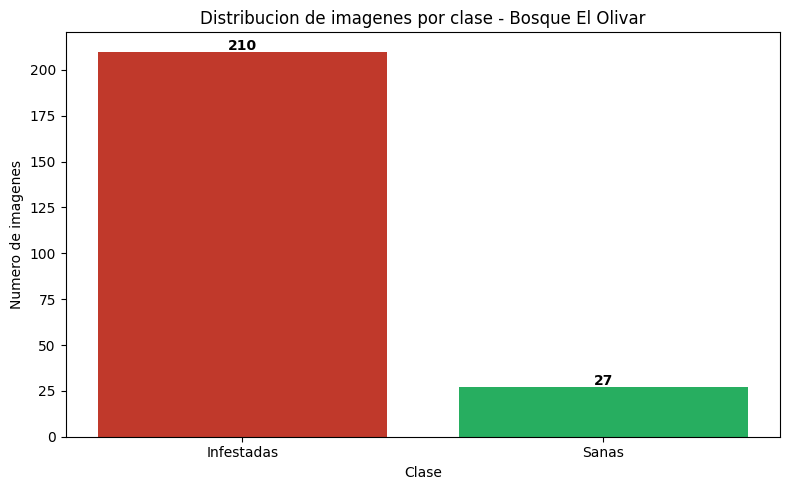

Grafica guardada.


In [22]:
# Grafica de distribucion de clases
clases = ['Infestadas', 'Sanas']
cantidades = [len(infestadas), len(sanas)]

plt.figure(figsize=(8, 5))
plt.bar(clases, cantidades, color=['#c0392b', '#27ae60'])
plt.title('Distribucion de imagenes por clase - Bosque El Olivar')
plt.xlabel('Clase')
plt.ylabel('Numero de imagenes')
for i, v in enumerate(cantidades):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('distribucion_clases.png')
plt.show()
print('Grafica guardada.')

## 4. Distribución de Dimensiones

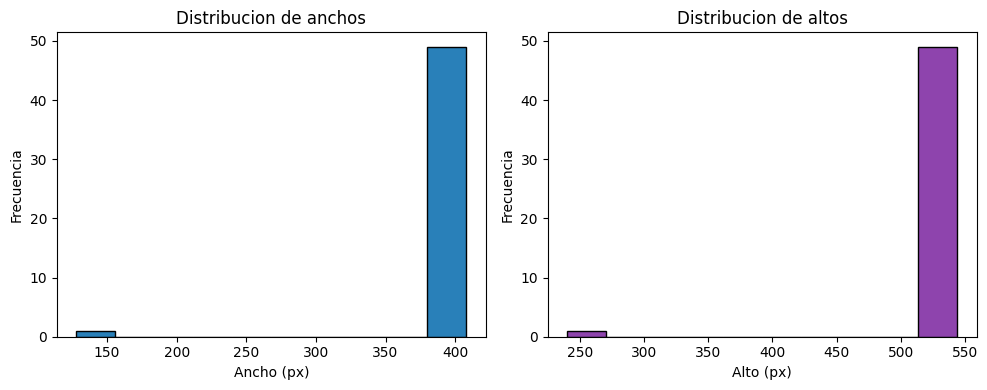

Histograma guardado.


In [23]:
# Histograma de anchos de imagenes
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(anchos, bins=10, color='#2980b9', edgecolor='black')
plt.title('Distribucion de anchos')
plt.xlabel('Ancho (px)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
plt.hist(altos, bins=10, color='#8e44ad', edgecolor='black')
plt.title('Distribucion de altos')
plt.xlabel('Alto (px)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('distribucion_dimensiones.png')
plt.show()
print('Histograma guardado.')

## 5. Resumen EDA y Riesgos Identificados

In [24]:
# Resumen del EDA
print("===== RESUMEN DEL ANALISIS EXPLORATORIO =====")
print()
print("DATASET:")
print(f"  Total de imagenes        : {len(infestadas) + len(sanas)}")
print(f"  Imagenes infestadas      : {len(infestadas)}")
print(f"  Imagenes sanas           : {len(sanas)}")
print()
print("DIMENSIONES:")
print(f"  Ancho promedio           : {int(np.mean(anchos))} px")
print(f"  Alto promedio            : {int(np.mean(altos))} px")
print(f"  Rango de anchos          : {int(np.min(anchos))} - {int(np.max(anchos))} px")
print(f"  Rango de altos           : {int(np.min(altos))} - {int(np.max(altos))} px")
print()
print("RIESGOS IDENTIFICADOS:")
print("  1. Desbalance de clases: 210 infestadas vs 0 sanas.")
print("     Accion: Capturar imagenes de hojas sanas y aplicar aumento de datos.")
print("  2. Tamano heterogeneo: imagenes entre 128px y 408px de ancho.")
print("     Accion: Estandarizar todas las imagenes a 640x640 px en preprocesamiento.")
print("  3. Variabilidad de iluminacion: fotos tomadas en diferentes horas del dia.")
print("     Accion: Aplicar normalizacion de brillo en preprocesamiento.")
print()
print("CONCLUSIONES ACCIONABLES:")
print("  1. Recolectar minimo 100 imagenes de hojas sanas para balancear el dataset.")
print("  2. Aplicar aumento de datos (rotacion, brillo, contraste) para ampliar")
print("     el dataset hasta aproximadamente 1000 imagenes antes del entrenamiento.")
print("=========================================")

===== RESUMEN DEL ANALISIS EXPLORATORIO =====

DATASET:
  Total de imagenes        : 237
  Imagenes infestadas      : 210
  Imagenes sanas           : 27

DIMENSIONES:
  Ancho promedio           : 402 px
  Alto promedio            : 537 px
  Rango de anchos          : 128 - 408 px
  Rango de altos           : 240 - 544 px

RIESGOS IDENTIFICADOS:
  1. Desbalance de clases: 210 infestadas vs 0 sanas.
     Accion: Capturar imagenes de hojas sanas y aplicar aumento de datos.
  2. Tamano heterogeneo: imagenes entre 128px y 408px de ancho.
     Accion: Estandarizar todas las imagenes a 640x640 px en preprocesamiento.
  3. Variabilidad de iluminacion: fotos tomadas en diferentes horas del dia.
     Accion: Aplicar normalizacion de brillo en preprocesamiento.

CONCLUSIONES ACCIONABLES:
  1. Recolectar minimo 100 imagenes de hojas sanas para balancear el dataset.
  2. Aplicar aumento de datos (rotacion, brillo, contraste) para ampliar
     el dataset hasta aproximadamente 1000 imagenes antes de

## 6. Visualización de Muestras

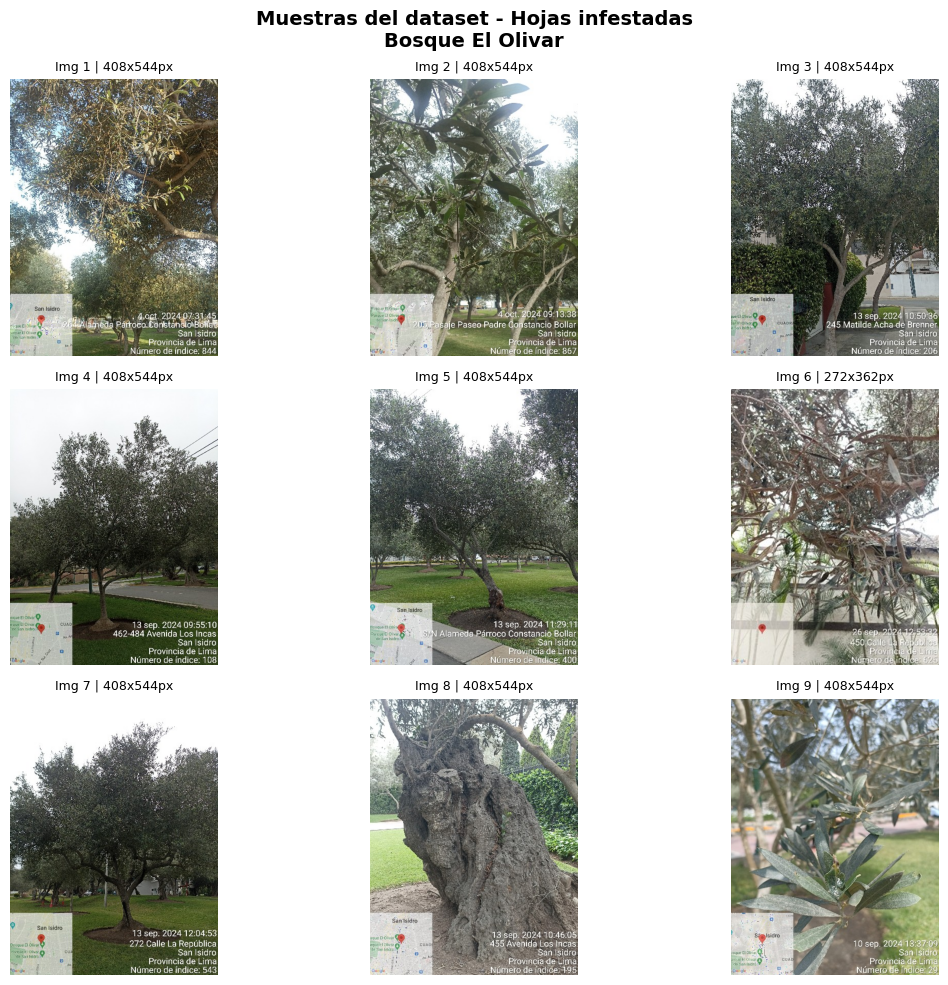

Visualizacion guardada.


In [25]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Mostrar 9 imagenes de muestra
muestra = random.sample(infestadas, min(9, len(infestadas)))

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle('Muestras del dataset - Hojas infestadas\nBosque El Olivar',
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    img = Image.open(muestra[i])
    ax.imshow(img)
    ax.set_title(f'Img {i+1} | {img.size[0]}x{img.size[1]}px', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('muestras_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualizacion guardada.')

## 7. Análisis de Canales RGB

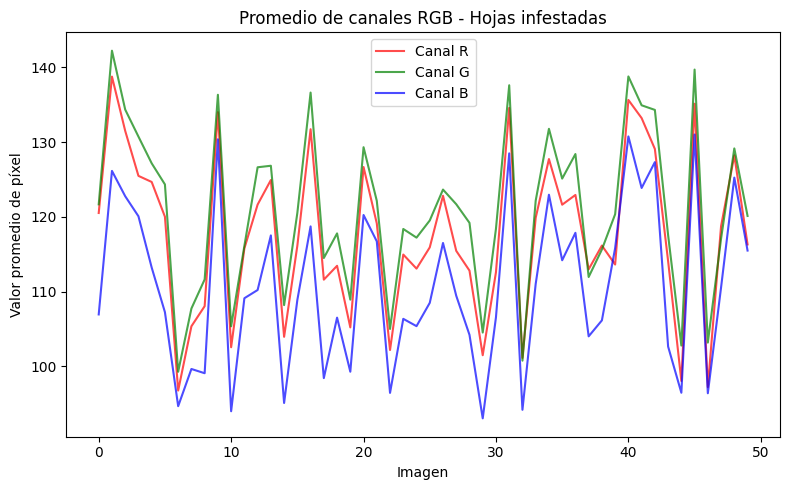

Análisis RGB guardado.


In [26]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

r_vals, g_vals, b_vals = [], [], []

for img_path in infestadas[:50]:
    try:
        img = np.array(Image.open(img_path).convert('RGB'))
        r_vals.append(img[:,:,0].mean())
        g_vals.append(img[:,:,1].mean())
        b_vals.append(img[:,:,2].mean())
    except:
        pass

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(r_vals, color='red', alpha=0.7, label='Canal R')
ax.plot(g_vals, color='green', alpha=0.7, label='Canal G')
ax.plot(b_vals, color='blue', alpha=0.7, label='Canal B')
ax.set_title('Promedio de canales RGB - Hojas infestadas')
ax.set_xlabel('Imagen')
ax.set_ylabel('Valor promedio de píxel')
ax.legend()
plt.tight_layout()
plt.savefig('analisis_rgb.png', dpi=150, bbox_inches='tight')
plt.show()
print('Análisis RGB guardado.')

## 8. Baseline Mínimo

In [27]:
import numpy as np
from PIL import Image
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

# Extraer features simples: media RGB de cada imagen
X, y = [], []

for img_path in infestadas:
    try:
        img = np.array(Image.open(img_path).convert('RGB').resize((64, 64)))
        features = [img[:,:,0].mean(), img[:,:,1].mean(), img[:,:,2].mean()]
        X.append(features)
        y.append(1)  # clase 1 = infestada
    except:
        pass

X = np.array(X)
y = np.array(y)

print(f'Features extraídas: {X.shape}')
print(f'Clases: {np.unique(y, return_counts=True)}')
print()
print('NOTA: Dataset actual tiene solo clase infestada (210 imgs, 0 sanas).')
print('Baseline ejecutado como prueba de pipeline.')
print('Se completará con clase sana una vez capturadas las imágenes.')

# Dummy classifier como baseline
clf = DummyClassifier(strategy='most_frequent')
clf.fit(X, y)
y_pred = clf.predict(X)
print()
print('=== BASELINE (DummyClassifier) ===')
print(classification_report(y, y_pred, target_names=['Infestada']))

Features extraídas: (210, 3)
Clases: (array([1]), array([210]))

NOTA: Dataset actual tiene solo clase infestada (210 imgs, 0 sanas).
Baseline ejecutado como prueba de pipeline.
Se completará con clase sana una vez capturadas las imágenes.

=== BASELINE (DummyClassifier) ===
              precision    recall  f1-score   support

   Infestada       1.00      1.00      1.00       210

    accuracy                           1.00       210
   macro avg       1.00      1.00      1.00       210
weighted avg       1.00      1.00      1.00       210



In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from PIL import Image

# Construir dataset desde cero con ambas clases
X2, y2 = [], []

for img_path in infestadas:
    try:
        img = np.array(Image.open(img_path).convert('RGB').resize((64, 64)))
        features = [img[:,:,0].mean(), img[:,:,1].mean(), img[:,:,2].mean()]
        X2.append(features)
        y2.append(1)
    except:
        pass

for img_path in sanas:
    try:
        img = np.array(Image.open(img_path).convert('RGB').resize((64, 64)))
        features = [img[:,:,0].mean(), img[:,:,1].mean(), img[:,:,2].mean()]
        X2.append(features)
        y2.append(0)
    except:
        pass

X2 = np.array(X2)
y2 = np.array(y2)

print(f'Dataset completo: {X2.shape}')
print(f'Infestadas: {sum(y2==1)} | Sanas: {sum(y2==0)}')

X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

clf_lr = LogisticRegression(random_state=42)
clf_lr.fit(X_train, y_train)
y_pred = clf_lr.predict(X_test)

print()
print('=== BASELINE: Regresión Logística ===')
print(classification_report(y_test, y_pred,
      target_names=['Sana', 'Infestada']))
print('Matriz de confusión:')
print(confusion_matrix(y_test, y_pred))

Dataset completo: (227, 3)
Infestadas: 210 | Sanas: 17

=== BASELINE: Regresión Logística ===
              precision    recall  f1-score   support

        Sana       0.00      0.00      0.00         3
   Infestada       0.93      1.00      0.97        43

    accuracy                           0.93        46
   macro avg       0.47      0.50      0.48        46
weighted avg       0.87      0.93      0.90        46

Matriz de confusión:
[[ 0  3]
 [ 0 43]]


## 9. Próximos Pasos

In [28]:
print("=== PRÓXIMOS PASOS ===")
print()
print("1. Capturar imágenes de hojas sanas (mínimo 100 imágenes)")
print("   para balancear el dataset (actualmente 210/0)")
print()
print("2. Con dataset balanceado:")
print("   - Reentrenar baseline con clasificación binaria real")
print("   - Experimentar con Variante 1: features HOG + SVM")
print("   - Experimentar con Variante 2: ResNet50 transfer learning")
print()
print("3. Preparar tabla comparativa:")
print("   Baseline vs Variante 1 vs Variante 2")
print("   Métricas: Precision, Recall, F1, mAP@0.5")

=== PRÓXIMOS PASOS ===

1. Capturar imágenes de hojas sanas (mínimo 100 imágenes)
   para balancear el dataset (actualmente 210/0)

2. Con dataset balanceado:
   - Reentrenar baseline con clasificación binaria real
   - Experimentar con Variante 1: features HOG + SVM
   - Experimentar con Variante 2: ResNet50 transfer learning

3. Preparar tabla comparativa:
   Baseline vs Variante 1 vs Variante 2
   Métricas: Precision, Recall, F1, mAP@0.5


## 10. Variante 1: HOG + SVM

In [31]:
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import numpy as np

# Extraer features HOG
X_hog, y_hog = [], []

for img_path in infestadas:
    try:
        img = np.array(Image.open(img_path).convert('L').resize((64, 64)))
        features = hog(img, orientations=8, pixels_per_cell=(8,8),
                      cells_per_block=(2,2))
        X_hog.append(features)
        y_hog.append(1)
    except:
        pass

for img_path in sanas:
    try:
        img = np.array(Image.open(img_path).convert('L').resize((64, 64)))
        features = hog(img, orientations=8, pixels_per_cell=(8,8),
                      cells_per_block=(2,2))
        X_hog.append(features)
        y_hog.append(0)
    except:
        pass

X_hog = np.array(X_hog)
y_hog = np.array(y_hog)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_hog, y_hog, test_size=0.2, random_state=42, stratify=y_hog)

clf_svm = SVC(kernel='rbf', random_state=42)
clf_svm.fit(X_train_h, y_train_h)
y_pred_h = clf_svm.predict(X_test_h)

print('=== VARIANTE 1: HOG + SVM ===')
print(classification_report(y_test_h, y_pred_h,
      target_names=['Sana', 'Infestada']))
print('Matriz de confusión:')
print(confusion_matrix(y_test_h, y_pred_h))

=== VARIANTE 1: HOG + SVM ===
              precision    recall  f1-score   support

        Sana       0.00      0.00      0.00         3
   Infestada       0.93      1.00      0.97        43

    accuracy                           0.93        46
   macro avg       0.47      0.50      0.48        46
weighted avg       0.87      0.93      0.90        46

Matriz de confusión:
[[ 0  3]
 [ 0 43]]


## 11. Variante 2: ResNet50 Transfer Learning

In [32]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from PIL import Image
import numpy as np

# Cargar ResNet50 sin capa final
base_model = ResNet50(weights='imagenet', include_top=False,
                      pooling='avg', input_shape=(64,64,3))

# Extraer features
X_res, y_res = [], []

for img_path in infestadas:
    try:
        img = Image.open(img_path).convert('RGB').resize((64,64))
        arr = preprocess_input(np.array(img).astype(float))
        X_res.append(arr)
        y_res.append(1)
    except:
        pass

for img_path in sanas:
    try:
        img = Image.open(img_path).convert('RGB').resize((64,64))
        arr = preprocess_input(np.array(img).astype(float))
        X_res.append(arr)
        y_res.append(0)
    except:
        pass

X_res = np.array(X_res)
features_res = base_model.predict(X_res, verbose=0)
y_res = np.array(y_res)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    features_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

clf_res = LogisticRegression(random_state=42, max_iter=1000)
clf_res.fit(X_train_r, y_train_r)
y_pred_r = clf_res.predict(X_test_r)

print('=== VARIANTE 2: ResNet50 + Regresión Logística ===')
print(classification_report(y_test_r, y_pred_r,
      target_names=['Sana', 'Infestada']))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
=== VARIANTE 2: ResNet50 + Regresión Logística ===
              precision    recall  f1-score   support

        Sana       0.67      0.67      0.67         3
   Infestada       0.98      0.98      0.98        43

    accuracy                           0.96        46
   macro avg       0.82      0.82      0.82        46
weighted avg       0.96      0.96      0.96        46



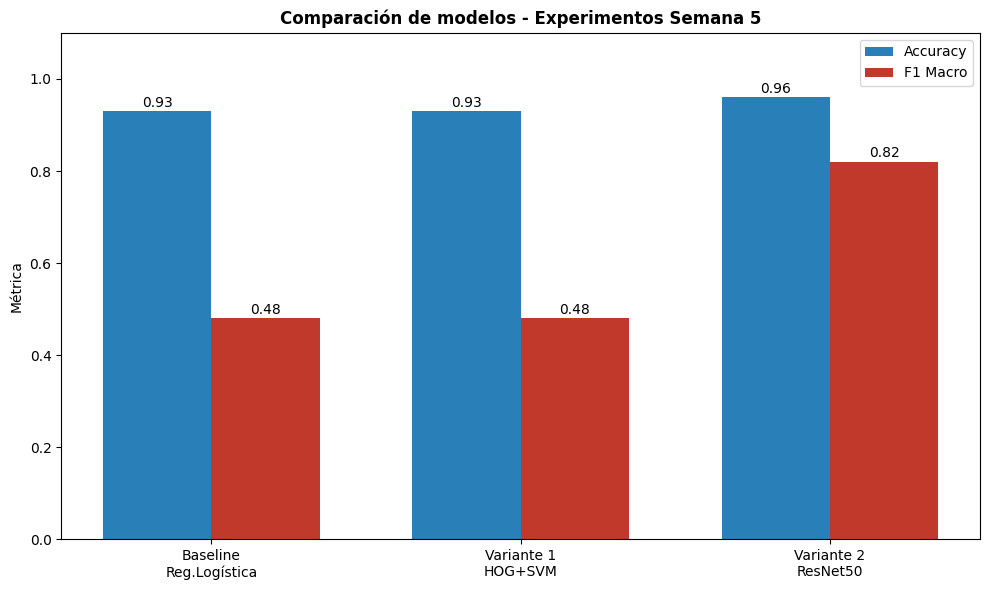

Gráfico guardado.


In [33]:
import matplotlib.pyplot as plt
import numpy as np

modelos = ['Baseline\nReg.Logística', 'Variante 1\nHOG+SVM', 'Variante 2\nResNet50']
accuracy = [0.93, 0.93, 0.96]
f1_macro = [0.48, 0.48, 0.82]

x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='#2980b9')
bars2 = ax.bar(x + width/2, f1_macro, width, label='F1 Macro', color='#c0392b')

ax.set_title('Comparación de modelos - Experimentos Semana 5', fontweight='bold')
ax.set_ylabel('Métrica')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado.')

## 12. Validación Cruzada (Cross Validation)

In [34]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Cross validation con 5 folds estratificado
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CV sobre Baseline
scores_lr = cross_val_score(clf_lr, X2, y2, cv=cv, scoring='f1_macro')
print('=== CROSS VALIDATION (5-Fold Estratificado) ===')
print()
print(f'Baseline (Reg. Logística):')
print(f'  F1 Macro por fold: {scores_lr.round(2)}')
print(f'  F1 Macro promedio: {scores_lr.mean():.2f} (+/- {scores_lr.std():.2f})')

# CV sobre ResNet50
scores_res = cross_val_score(clf_res, features_res, y_res, cv=cv, scoring='f1_macro')
print()
print(f'Variante 2 (ResNet50):')
print(f'  F1 Macro por fold: {scores_res.round(2)}')
print(f'  F1 Macro promedio: {scores_res.mean():.2f} (+/- {scores_res.std():.2f})')

=== CROSS VALIDATION (5-Fold Estratificado) ===

Baseline (Reg. Logística):
  F1 Macro por fold: [0.68 0.68 0.48 0.48 0.74]
  F1 Macro promedio: 0.61 (+/- 0.11)

Variante 2 (ResNet50):
  F1 Macro por fold: [1.   0.82 0.89 0.81 0.82]
  F1 Macro promedio: 0.87 (+/- 0.07)
